# Random Forest

## Data provenance note — sample exclusion (2026-09-04)

Ten samples recorded at **2% DMSO** (original `INDEX` 1-10, all with 0% trehalose
and 98% SFB) were **removed from the dataset**. A provenance check concluded that
these measurements were not produced by this research group, and that the
experimental conditions under which they were obtained are neither known nor
documented. Because their origin and methodology cannot be attested, they were
excluded in full. The decision was taken by the authors responsible for the
experiments.

- Removed: 10 samples; criterion: `% DMSO == 2.0`; date: 2026-09-04.
- Dataset size: **216 -> 206 samples**.
- The `INDEX` column of the remaining rows was deliberately **not renumbered**
  (it now starts at 11) so every row stays traceable to the original bench
  spreadsheets.
- The previous version of `data/raw/hepg2.csv` is preserved in the git history;
  no commented-out rows and no `hepg2_old.csv` copy are kept in the repository.

All models in this repository were retrained from scratch on the 206-sample
dataset and every derived result was recomputed.


In [1]:
import random
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve

# ── Determinism ──────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Visual settings for plots
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12})

## Data Loading

## Split structure
```
Full dataset  (206 samples)
  └─ Test set   (42 samples, 20%)  ← held out from training; same partition reported for every model
  └─ Train set  (164 samples, 80%) ← used for training + KFold CV
```
KFold (5 folds) runs over the 164-sample training set (same seed=42 across all notebooks).


In [2]:
caminho_arquivo = '../data/raw/hepg2.csv'
df = pd.read_csv(caminho_arquivo)

display(df.head())

X = df[['% DMSO', 'TREHALOSE']]
y = df['VIABILIDADE']

,INDEX,ESPÉCIE/LINHAGEM,% DMSO,TREHALOSE,% SFB,VIABILIDADE
0,11,HepG2,5.0,0.0,95.0,96.80
1,12,HepG2,5.0,0.0,95.0,94.45
2,13,HepG2,5.0,0.0,95.0,96.00
3,14,HepG2,5.0,0.0,95.0,95.07
4,15,HepG2,5.0,0.0,95.0,90.00


## Dataset Split and Model Training

In [3]:
# Split data: 80% train, 20% test (seed=42; same across all notebooks)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Guard: the whole analysis assumes the 206-sample dataset. Fail loudly if the
# split sizes ever drift instead of silently reporting numbers for other data.
EXPECTED = {'total': 206, 'trainval': 164, 'test': 42}
actual = {'total': len(df), 'trainval': len(X_train), 'test': len(X_test)}
print(f'Split check -> total={actual["total"]} | train+val={actual["trainval"]} | test={actual["test"]}')
assert actual == EXPECTED, f'Unexpected split sizes: {actual} != {EXPECTED}'
print('Split sizes match the expected 206 / 164 / 42.')

rf_model = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_model.fit(X_train, y_train)

print('Random Forest model trained successfully.')


Split check -> total=206 | train+val=164 | test=42
Split sizes match the expected 206 / 164 / 42.
Random Forest model trained successfully.


## Validation

In [4]:
y_pred = rf_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# KFold over the 80% train set (same cv object used in alternatives.ipynb)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='r2')
mean_cv_r2 = cv_scores.mean()
std_cv_r2  = cv_scores.std()

rmse_cv_scores = []
from sklearn.model_selection import cross_validate
cv_results = cross_validate(
    rf_model, X_train, y_train, cv=cv,
    scoring='neg_root_mean_squared_error'
)
mean_cv_rmse = -cv_results['test_score'].mean()
std_cv_rmse  =  cv_results['test_score'].std()

print(f'Test performance  -> R²: {r2:.4f} | RMSE: {rmse:.4f}%')
print(f'KFold CV (5-fold) -> Mean R²: {mean_cv_r2:.4f} ± {std_cv_r2:.4f}')
print(f'KFold CV (5-fold) -> Mean RMSE: {mean_cv_rmse:.4f}% ± {std_cv_rmse:.4f}%')

Test performance  -> R²: 0.9840 | RMSE: 4.6043%
KFold CV (5-fold) -> Mean R²: 0.9598 ± 0.0131
KFold CV (5-fold) -> Mean RMSE: 6.9691% ± 1.0810%


## Simulating all possible concentrations

In [5]:
# Exhaustive grid search over the concentration space, in 1% steps.
# Only physically meaningful mixtures are kept: DMSO + Trehalose <= 100%.
dmso_range = np.arange(0, 101, 1.0)
treh_range = np.arange(0, 101, 1.0)

combinacoes = [(d, t) for d, t in itertools.product(dmso_range, treh_range) if d + t <= 100]
df_simulacao = pd.DataFrame(combinacoes, columns=['% DMSO', 'TREHALOSE'])
df_simulacao['PREDICTED_VIABILITY'] = rf_model.predict(df_simulacao[['% DMSO', 'TREHALOSE']])
print(f'Grid points evaluated: {len(df_simulacao)} (step 1%, DMSO + Trehalose <= 100%)')


def tied_at_max(frame):
    """Return (best_value, all rows tied at that exact value).

    The Random Forest predicts by piecewise-constant regions, so every optimum
    is a PLATEAU rather than a single point: many grid combinations fall in the
    same leaf of every tree and therefore share a bit-identical prediction.
    Taking an arbitrary argmax would report one point out of many equally good
    ones, so the whole tied set is returned and reported as a range.
    """
    best = frame['PREDICTED_VIABILITY'].max()
    tied = frame[frame['PREDICTED_VIABILITY'] == best].sort_values(['% DMSO', 'TREHALOSE'])
    return float(best), tied


best_global_viab, global_tied = tied_at_max(df_simulacao)
best_dmso_viab, dmso_tied = tied_at_max(df_simulacao[df_simulacao['TREHALOSE'] == 0])
best_treh_viab, treh_tied = tied_at_max(df_simulacao[df_simulacao['% DMSO'] == 0])
best_comb_viab, comb_tied = tied_at_max(
    df_simulacao[(df_simulacao['% DMSO'] > 0) & (df_simulacao['TREHALOSE'] > 0)]
)


def report(title, viab, tied):
    print()
    print(f'--- {title} ---')
    print(f'  predicted viability: {viab:.4f}%  ({len(tied)} tied grid combination(s))')
    print(f'  DMSO range:      {tied["% DMSO"].min():.0f}-{tied["% DMSO"].max():.0f}%')
    print(f'  Trehalose range: {tied["TREHALOSE"].min():.0f}-{tied["TREHALOSE"].max():.0f}%')
    display(tied.head(20))


report('BEST GLOBAL COMBINATION (plateau)', best_global_viab, global_tied)
report('BEST DMSO ALONE (no trehalose)', best_dmso_viab, dmso_tied)
report('BEST TREHALOSE ALONE (no DMSO)', best_treh_viab, treh_tied)
report('BEST COMBINED USE (both present)', best_comb_viab, comb_tied)


Grid points evaluated: 5151 (step 1%, DMSO + Trehalose <= 100%)

--- BEST GLOBAL COMBINATION (plateau) ---
  predicted viability: 92.6662%  (15 tied grid combination(s))
  DMSO range:      13-17%
  Trehalose range: 0-2%


,% DMSO,TREHALOSE,PREDICTED_VIABILITY
1235,13.0,0.0,92.666207
1236,13.0,1.0,92.666207
1237,13.0,2.0,92.666207
1323,14.0,0.0,92.666207
1324,14.0,1.0,92.666207
1325,14.0,2.0,92.666207
1410,15.0,0.0,92.666207
1411,15.0,1.0,92.666207
1412,15.0,2.0,92.666207
1496,16.0,0.0,92.666207



--- BEST DMSO ALONE (no trehalose) ---
  predicted viability: 92.6662%  (5 tied grid combination(s))
  DMSO range:      13-17%
  Trehalose range: 0-0%


,% DMSO,TREHALOSE,PREDICTED_VIABILITY
1235,13.0,0.0,92.666207
1323,14.0,0.0,92.666207
1410,15.0,0.0,92.666207
1496,16.0,0.0,92.666207
1581,17.0,0.0,92.666207



--- BEST TREHALOSE ALONE (no DMSO) ---
  predicted viability: 77.5665%  (10 tied grid combination(s))
  DMSO range:      0-0%
  Trehalose range: 16-25%


,% DMSO,TREHALOSE,PREDICTED_VIABILITY
16,0.0,16.0,77.566513
17,0.0,17.0,77.566513
18,0.0,18.0,77.566513
19,0.0,19.0,77.566513
20,0.0,20.0,77.566513
21,0.0,21.0,77.566513
22,0.0,22.0,77.566513
23,0.0,23.0,77.566513
24,0.0,24.0,77.566513
25,0.0,25.0,77.566513



--- BEST COMBINED USE (both present) ---
  predicted viability: 92.6662%  (10 tied grid combination(s))
  DMSO range:      13-17%
  Trehalose range: 1-2%


,% DMSO,TREHALOSE,PREDICTED_VIABILITY
1236,13.0,1.0,92.666207
1237,13.0,2.0,92.666207
1324,14.0,1.0,92.666207
1325,14.0,2.0,92.666207
1411,15.0,1.0,92.666207
1412,15.0,2.0,92.666207
1497,16.0,1.0,92.666207
1498,16.0,2.0,92.666207
1582,17.0,1.0,92.666207
1583,17.0,2.0,92.666207


## Data Visualization

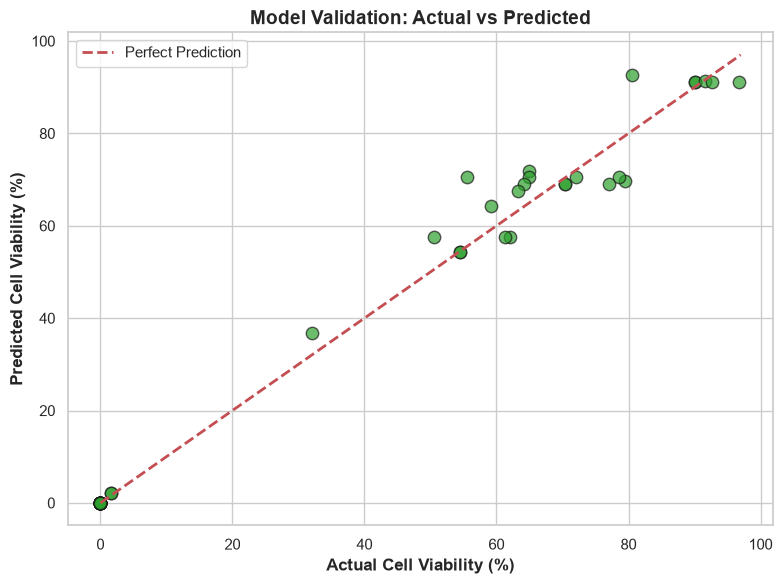

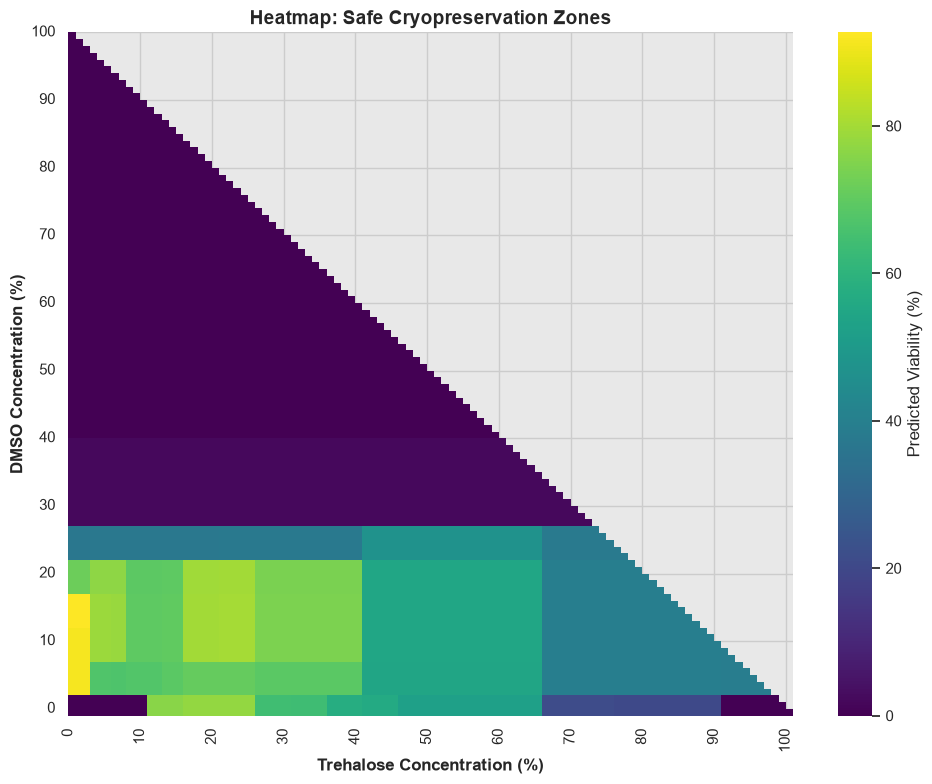

In [6]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='#2ca02c', edgecolor='k', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Cell Viability (%)', fontweight='bold')
plt.ylabel('Predicted Cell Viability (%)', fontweight='bold')
plt.title('Model Validation: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../static/images/rf_actual_vs_predicted.png', dpi=300)
plt.show()

# Plot 2: Viability Heatmap.
# The simulation grid only covers DMSO + Trehalose <= 100%, so the pivot is
# reindexed onto the full 0-100 x 0-100 square and the infeasible upper-right
# triangle is left as NaN (drawn in light grey by the mask).
matriz_calor = (
    df_simulacao
    .pivot(index='% DMSO', columns='TREHALOSE', values='PREDICTED_VIABILITY')
    .reindex(index=np.arange(0, 101, 1.0), columns=np.arange(0, 101, 1.0))
)
plt.figure(figsize=(10, 8))
ax = sns.heatmap(matriz_calor.iloc[::-1], cmap='viridis',
                 mask=matriz_calor.iloc[::-1].isna(),
                 cbar_kws={'label': 'Predicted Viability (%)'})
ax.set_facecolor('#e8e8e8')
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels(np.arange(0, 101, 10))
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels(np.arange(100, -1, -10))
plt.title('Heatmap: Safe Cryopreservation Zones', fontsize=14, fontweight='bold')
plt.xlabel('Trehalose Concentration (%)', fontweight='bold')
plt.ylabel('DMSO Concentration (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('../static/images/rf_viability_heatmap.png', dpi=300)
plt.show()


## Exporting the .pkl model and metrics for web use

In [7]:
caminho_modelo = '../models/random_forest_model.pkl'
joblib.dump(rf_model, caminho_modelo)
print(f'Model exported to: {caminho_modelo}')


def tied_payload(tied, viab, note):
    """Serialize a plateau of tied grid combinations for metrics.json."""
    return {
        'note': note,
        'dmso_range': [float(tied['% DMSO'].min()), float(tied['% DMSO'].max())],
        'trehalose_range': [float(tied['TREHALOSE'].min()), float(tied['TREHALOSE'].max())],
        'viability': round(viab, 2),
        'combinations': [
            {'dmso': float(r['% DMSO']), 'trehalose': float(r['TREHALOSE'])}
            for _, r in tied.iterrows()
        ],
    }


PLATEAU_NOTE = (
    'The Random Forest predicts by constant regions, so this optimum is a plateau, '
    'not a single point. Every combination listed here (grid step 1%, sum <= 100%) is '
    'tied at the exact same predicted value. Report as a range, not a single '
    'arbitrarily-chosen point.'
)

best_combinations = {
    # The single-point entries below are the lowest-concentration member of each
    # plateau, kept only so existing consumers keep working; the *_tied entries
    # are the honest answer and are what the templates render.
    'global': {'dmso': float(global_tied['% DMSO'].iloc[0]),
               'trehalose': float(global_tied['TREHALOSE'].iloc[0]),
               'viability': round(best_global_viab, 2)},
    'dmso_only': {'dmso': float(dmso_tied['% DMSO'].iloc[0]), 'trehalose': 0.0,
                  'viability': round(best_dmso_viab, 2)},
    'treh_only': {'dmso': 0.0, 'trehalose': float(treh_tied['TREHALOSE'].iloc[0]),
                  'viability': round(best_treh_viab, 2)},
    'global_tied': tied_payload(global_tied, best_global_viab, PLATEAU_NOTE),
    'dmso_only_tied': tied_payload(dmso_tied, best_dmso_viab, PLATEAU_NOTE),
    'treh_only_tied': tied_payload(treh_tied, best_treh_viab, PLATEAU_NOTE),
}

rf_metrics = {
    'features': ['% DMSO', 'TREHALOSE'],
    'r2_test': round(float(r2), 4),
    'rmse_test': round(float(rmse), 4),
    'cv_r2_mean': round(float(mean_cv_r2), 4),
    'cv_r2_std': round(float(std_cv_r2), 4),
    'cv_rmse_mean': round(float(mean_cv_rmse), 4),
    'cv_rmse_std': round(float(std_cv_rmse), 4),
    'best_combinations': best_combinations,
    'hyperparameters': {'n_estimators': 200, 'random_state': SEED},
}

print()
print('Random Forest metrics:')
for k, v in rf_metrics.items():
    if k != 'best_combinations':
        print(f'  {k}: {v}')
print('  best_combinations:')
for strat in ('global_tied', 'dmso_only_tied', 'treh_only_tied'):
    p = best_combinations[strat]
    print(f"    {strat}: viability={p['viability']}% | DMSO {p['dmso_range']} | "
          f"Trehalose {p['trehalose_range']} | {len(p['combinations'])} tied")


def predict_for_physician(dmso_input, trehalose_input):
    if dmso_input < 0 or trehalose_input < 0:
        return 'Error: Concentrations cannot be negative.'
    if dmso_input + trehalose_input > 100:
        return 'Error: Sum exceeds total volume (100%).'
    entrada = pd.DataFrame({'% DMSO': [dmso_input], 'TREHALOSE': [trehalose_input]})
    modelo_carregado = joblib.load(caminho_modelo)
    viabilidade = modelo_carregado.predict(entrada)[0]
    return (f'The combination of {dmso_input}% DMSO and {trehalose_input}% trehalose '
            f'will result in cell viability of approximately {viabilidade:.2f}%.')


print()
print(predict_for_physician(10.0, 0.0))
print(predict_for_physician(50.0, 10.0))


Model exported to: ../models/random_forest_model.pkl

Random Forest metrics:
  features: ['% DMSO', 'TREHALOSE']
  r2_test: 0.984
  rmse_test: 4.6043
  cv_r2_mean: 0.9598
  cv_r2_std: 0.0131
  cv_rmse_mean: 6.9691
  cv_rmse_std: 1.081
  hyperparameters: {'n_estimators': 200, 'random_state': 42}
  best_combinations:
    global_tied: viability=92.67% | DMSO [13.0, 17.0] | Trehalose [0.0, 2.0] | 15 tied
    dmso_only_tied: viability=92.67% | DMSO [13.0, 17.0] | Trehalose [0.0, 0.0] | 5 tied
    treh_only_tied: viability=77.57% | DMSO [0.0, 0.0] | Trehalose [16.0, 25.0] | 10 tied

The combination of 10.0% DMSO and 0.0% trehalose will result in cell viability of approximately 91.22%.
The combination of 50.0% DMSO and 10.0% trehalose will result in cell viability of approximately 0.00%.


## Extra Validation

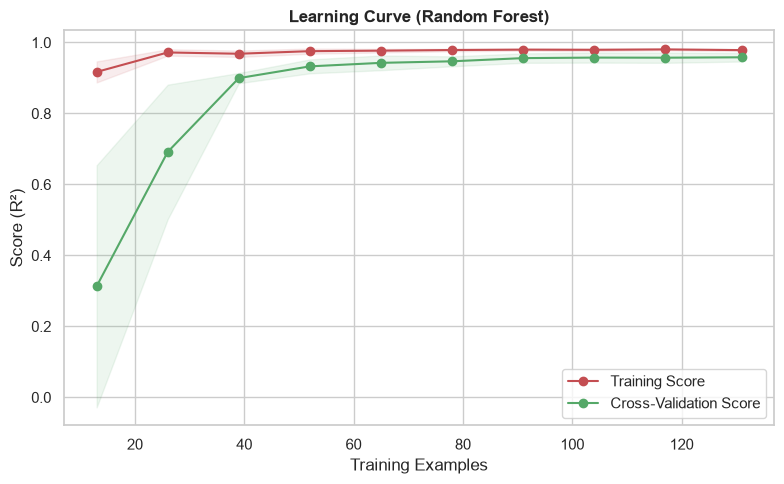

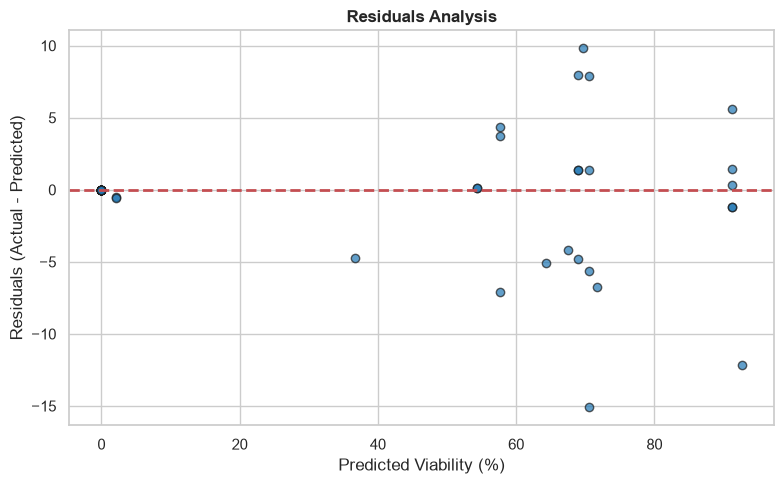

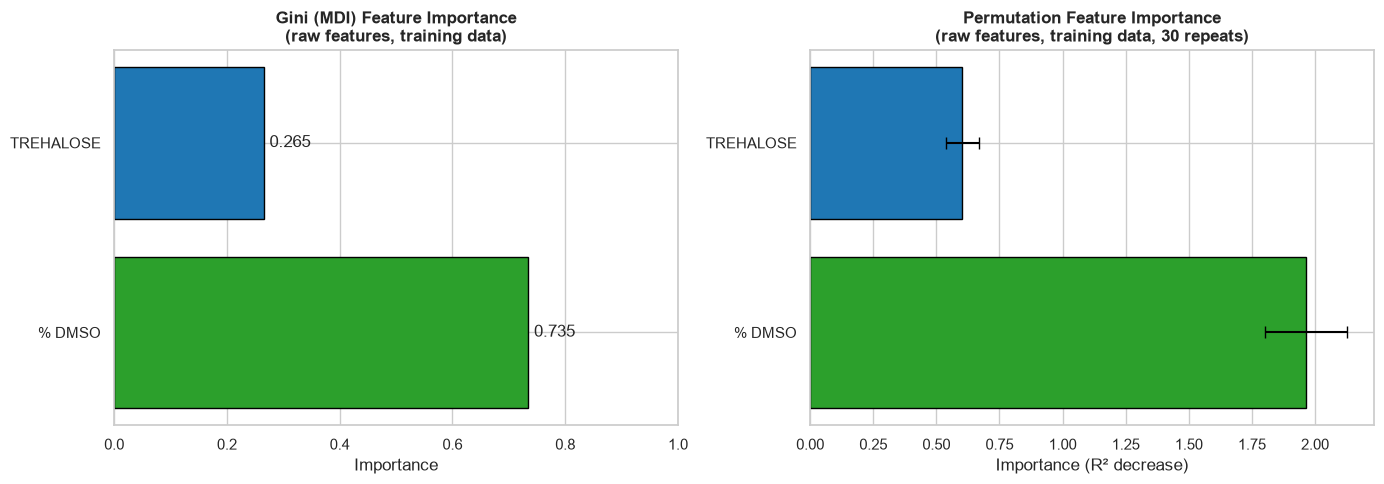


Gini importances:
  % DMSO: 0.7346
  TREHALOSE: 0.2654

Permutation importances (mean ± std):
  % DMSO: 1.9637 ± 0.1637
  TREHALOSE: 0.6033 ± 0.0637


In [8]:
# 1. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=cv, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, test_mean,  'o-', color='g', label='Cross-Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.1, color='g')
plt.title('Learning Curve (Random Forest)', fontweight='bold')
plt.xlabel('Training Examples')
plt.ylabel('Score (R²)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../static/images/rf_learning_curve.png', dpi=300)
plt.show()

# 2. Residuals Plot
residuos = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.7, color='#1f77b4', edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals Analysis', fontweight='bold')
plt.xlabel('Predicted Viability (%)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.savefig('../static/images/rf_residuals.png', dpi=300)
plt.show()

# 3. Feature Importance (Gini MDI — from model fitted on training data)
importancias    = rf_model.feature_importances_
feature_labels  = X.columns

# 4. Permutation Importance (evaluated on training set, 30 repeats)
perm = permutation_importance(
    rf_model, X_train, y_train, n_repeats=30, random_state=SEED, scoring='r2'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_labels, importancias, color=['#2ca02c', '#1f77b4'], edgecolor='black')
axes[0].set_xlabel('Importance')
axes[0].set_title('Gini (MDI) Feature Importance\n(raw features, training data)', fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(importancias):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

axes[1].barh(feature_labels, perm.importances_mean,
             xerr=perm.importances_std,
             color=['#2ca02c', '#1f77b4'], edgecolor='black',
             error_kw={'ecolor': 'black', 'capsize': 4})
axes[1].set_xlabel('Importance (R² decrease)')
axes[1].set_title('Permutation Feature Importance\n(raw features, training data, 30 repeats)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('../static/images/rf_feature_importance.png', dpi=300)
plt.show()

print('\nGini importances:')
for name, imp in zip(feature_labels, importancias):
    print(f'  {name}: {imp:.4f}')
print('\nPermutation importances (mean ± std):')
for name, m, s in zip(feature_labels, perm.importances_mean, perm.importances_std):
    print(f'  {name}: {m:.4f} ± {s:.4f}')

## NumPy Export and Acceptance Test

`models/rf_trees.npz` holds the 200 fitted trees flattened into concatenated arrays so
that `src/rf_inference.py` can reproduce `RandomForestRegressor.predict` with NumPy
alone -- the deployed app needs neither scikit-learn nor joblib.

`children_left` / `children_right` keep scikit-learn's original **local** (per-tree)
node indices; `offsets[k]` marks where tree *k*'s nodes begin in the flat arrays.

**Acceptance criterion:** on a dense grid (DMSO/Trehalose 0-100%, step 1%, sum <= 100%)
the NumPy predictions must differ from scikit-learn's by **exactly 0**.


In [9]:
# ---- Flatten the forest into concatenated arrays ----
feature_list, threshold_list = [], []
left_list, right_list, value_list = [], [], []
offsets, running = [], 0

for est in rf_model.estimators_:
    t = est.tree_
    offsets.append(running)
    feature_list.append(t.feature.astype(np.int64))
    threshold_list.append(t.threshold.astype(np.float64))
    # Local (per-tree) child indices are kept verbatim; -1 marks a leaf.
    left_list.append(t.children_left.astype(np.int64))
    right_list.append(t.children_right.astype(np.int64))
    value_list.append(t.value[:, 0, 0].astype(np.float64))
    running += t.node_count

rf_npz = {
    'feature': np.concatenate(feature_list),
    'threshold': np.concatenate(threshold_list),
    'children_left': np.concatenate(left_list),
    'children_right': np.concatenate(right_list),
    'value': np.concatenate(value_list),
    'offsets': np.array(offsets, dtype=np.int64),
    'n_estimators': np.int64(len(rf_model.estimators_)),
}

np.savez('../models/rf_trees.npz', **rf_npz)
print(f'Exported {rf_npz["n_estimators"]} trees, {len(rf_npz["feature"])} nodes total '
      f'-> ../models/rf_trees.npz')

# ---- Acceptance test: NumPy inference must match scikit-learn exactly ----
import importlib
sys.path.insert(0, '../src')
import rf_inference
importlib.reload(rf_inference)

grid_rf = np.array(
    [(d, t) for d, t in itertools.product(np.arange(0, 101, 1.0), np.arange(0, 101, 1.0))
     if d + t <= 100],
    dtype=np.float64,
)
print(f'Grid size: {len(grid_rf)} points (DMSO 0-100, Trehalose 0-100, step 1, sum <= 100)')

pred_sklearn = rf_model.predict(pd.DataFrame(grid_rf, columns=['% DMSO', 'TREHALOSE']))
pred_numpy = rf_inference.predict(grid_rf)

rf_max_abs_diff = float(np.max(np.abs(pred_sklearn - pred_numpy)))
rf_n_mismatch = int(np.count_nonzero(pred_sklearn != pred_numpy))
print(f'Max abs diff (scikit-learn vs NumPy): {rf_max_abs_diff!r}')
print(f'Mismatching grid points: {rf_n_mismatch} / {len(grid_rf)}')

# The web app predicts one row at a time, so the single-row path is checked
# separately: NumPy changes its summation strategy with array shape, and a
# batched match does not by itself guarantee a single-row match.
single_mismatch = sum(
    1 for (d, t), expected in zip(grid_rf, pred_sklearn)
    if rf_inference.predict_one(d, t) != expected
)
print(f'Single-row calls mismatching scikit-learn: {single_mismatch} / {len(grid_rf)}')

if rf_max_abs_diff == 0.0 and single_mismatch == 0:
    print('PASS: NumPy Random Forest export is bit-for-bit identical to scikit-learn,')
    print('      both batched and one row at a time.')
else:
    raise AssertionError('rf_trees.npz does not reproduce scikit-learn exactly -- fix before proceeding!')


Exported 200 trees, 8822 nodes total -> ../models/rf_trees.npz
Grid size: 5151 points (DMSO 0-100, Trehalose 0-100, step 1, sum <= 100)
Max abs diff (scikit-learn vs NumPy): 0.0
Mismatching grid points: 0 / 5151


Single-row calls mismatching scikit-learn: 0 / 5151
PASS: NumPy Random Forest export is bit-for-bit identical to scikit-learn,
      both batched and one row at a time.


## Writing `metrics.json`

`metrics.json` at the repository root is the single source of truth read by `app.py`,
by the templates and by the other notebooks. This notebook runs **first** and therefore
(re)creates the file, writing the `dataset` and `random_forest` sections. Notebooks
02-04 load it, add their own sections and write it back.


In [10]:
import json
from datetime import datetime

METRICS_PATH = '../metrics.json'

metrics = {
    'generated_at': datetime.now().replace(microsecond=0).isoformat(),
    'dataset': {
        'n_total': int(len(df)),
        'n_trainval': int(len(X_train)),
        'n_train_fit': 123,
        'n_val': 41,
        'n_test': int(len(X_test)),
        'split_seed': SEED,
        'excluded_samples': {
            'count': 10,
            'criterion': '% DMSO == 2.0',
            'original_index_range': [1, 10],
            'date': '2026-09-04',
            'reason': (
                'Provenance check concluded these measurements were not produced by this '
                'research group and that the experimental conditions under which they were '
                'obtained are neither known nor documented. Excluded in full by decision of '
                'the authors responsible for the experiments. INDEX values of the remaining '
                'rows were not renumbered, preserving traceability to the bench spreadsheets.'
            ),
            'dataset_size_before': 216,
            'dataset_size_after': 206,
        },
        'note': (
            'Split identical across 01_random_forest.ipynb, 02_neural_network.ipynb, '
            '03_model_comparison.ipynb and 04_baselines.ipynb (train_test_split, '
            'test_size=0.2, random_state=42; the NN further splits the 164 train+validation '
            'samples into 123 fit / 41 validation, test_size=0.25, random_state=42).'
        ),
    },
    'random_forest': dict(
        rf_metrics,
        # Gini (MDI) importances of the model fitted on the training set, plus the
        # permutation importances computed in the "Extra Validation" section above.
        feature_importance={
            name: round(float(imp), 4)
            for name, imp in zip(feature_labels, importancias)
        },
        permutation_importance={
            name: {'mean': round(float(m), 4), 'std': round(float(sd), 4)}
            for name, m, sd in zip(feature_labels, perm.importances_mean, perm.importances_std)
        },
    ),
    'random_forest_numpy_export_validation': {
        'grid_size': int(len(grid_rf)),
        'max_abs_diff': rf_max_abs_diff,
        'n_mismatching_points': rf_n_mismatch,
        'passed': rf_max_abs_diff == 0.0,
    },
}

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'Wrote {METRICS_PATH} with sections: {list(metrics)}')
print(f"  dataset: {metrics['dataset']['n_total']} samples "
      f"({metrics['dataset']['n_trainval']} train+val / {metrics['dataset']['n_test']} test)")
print(f"  feature importance: {metrics['random_forest']['feature_importance']}")


Wrote ../metrics.json with sections: ['generated_at', 'dataset', 'random_forest', 'random_forest_numpy_export_validation']
  dataset: 206 samples (164 train+val / 42 test)
  feature importance: {'% DMSO': 0.7346, 'TREHALOSE': 0.2654}
